In [1]:
print("hello world")

hello world


In [ ]:
import numpy as np
import pandas as pd

import torch 
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [5]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

100.0%
100.0%
100.0%
100.0%


Label: 1


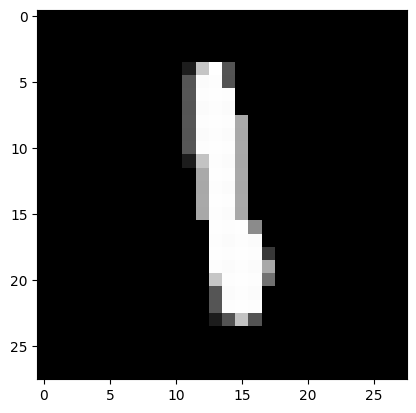

In [13]:

image, label = train_dataset[200]   # get first image

print("Label:", label)
plt.imshow(image.squeeze(), cmap="gray")
plt.show()

In [42]:
class Ann(nn.Module):
    def __init__(self):
        super(Ann, self).__init__()
        self.fc1=nn.Linear(28*28,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,10)
        self.relu=nn.ReLU()

    def forward(self,x):
        x=x.view(-1,28*28)
        x=self.relu(self.fc1(x))
        x=self.relu(self.fc2(x))
        x=self.fc3(x)
        return x

model=Ann()

In [43]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)


In [44]:
epochs=10
loss_list=[]
for epoch in range(epochs):
    running_loss=0

    for image, labels in train_loader:
        optimizer.zero_grad()
        output=model(image)
        loss=criterion(output,labels) 
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()
        
    epoch_loss=running_loss/len(train_loader)
    loss_list.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")




Epoch [1/10], Loss: 0.3404
Epoch [2/10], Loss: 0.1517
Epoch [3/10], Loss: 0.1128
Epoch [4/10], Loss: 0.0937
Epoch [5/10], Loss: 0.0774
Epoch [6/10], Loss: 0.0668
Epoch [7/10], Loss: 0.0582
Epoch [8/10], Loss: 0.0524
Epoch [9/10], Loss: 0.0479
Epoch [10/10], Loss: 0.0436


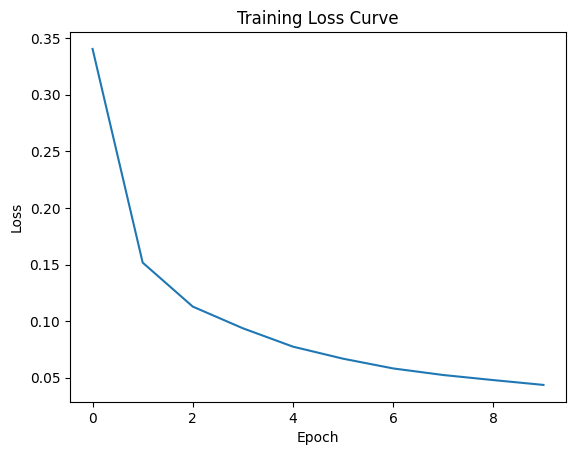

In [45]:
plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()


In [46]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 97.38%
